# 실습 - Titanic 호 data 를 이용한 Feature Engineering 과 Modeling

Pclass - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)  $\rightarrow$ 객실 등급  
survival -  Survival (0 = 사망; 1 = 생존)  $\rightarrow$ 생존여부  
name - Name  
sex - Sex  
age - Age  
sibsp - Number of Siblings/Spouses Aboard  $\rightarrow$ 함께 탑승한 형제 또는 배우자 수   
parch - Number of Parents/Children Aboard  $\rightarrow$ 함께 탑승한 부모 또는 자녀 수  
ticket - Ticket Number  
fare - Passenger Fare (British pound)  
cabin - Cabin  $\rightarrow$ 선실번호  
embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)  $\rightarrow$ 탑승한 항구(얼마나 부유한지와 관련)

In [1]:
# 필요한 라이브러리 import
import numpy as np  # 수치 연산
import pandas as pd  # 데이터프레임 처리
import matplotlib.pyplot as plt  # 그래프 시각화

In [2]:
# 타이타닉 데이터셋 로드
df_titanic = pd.read_csv("datasets/titanic.csv")

In [3]:
# 데이터셋의 크기 확인 (행 수, 열 수)
df_titanic.shape

(891, 12)

In [4]:
# 데이터셋의 처음 5개 행 확인
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# 불필요한 열 제거
# PassengerId: 고유 식별자 (모델링에 불필요)
# Name: 이름 (개인 식별 정보)
# Cabin: 선실번호 (결측치가 많음)
# Ticket: 티켓 번호 (개인 식별 정보)
# axis=1: 열 방향, inplace=True: 원본 데이터프레임 수정
df_titanic.drop(['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1, inplace=True)
# 열 제거 후 데이터 확인
df_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
# 데이터셋의 기본 정보 확인 (데이터 타입, 결측치 개수 등)
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [7]:
# 각 열의 결측치(null) 개수 확인
df_titanic.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [8]:
# 수치형 변수의 기술 통계량 확인 (평균, 표준편차, 최소값, 최대값 등)
df_titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Feature Analysis

- feature 간의 correlation check

- Survived 와 각 Feature 간 상관관계 파악

In [9]:
# 수치형 변수 간의 상관관계 행렬 계산
# numeric_only=True: 수치형 변수만 포함
df_titanic.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


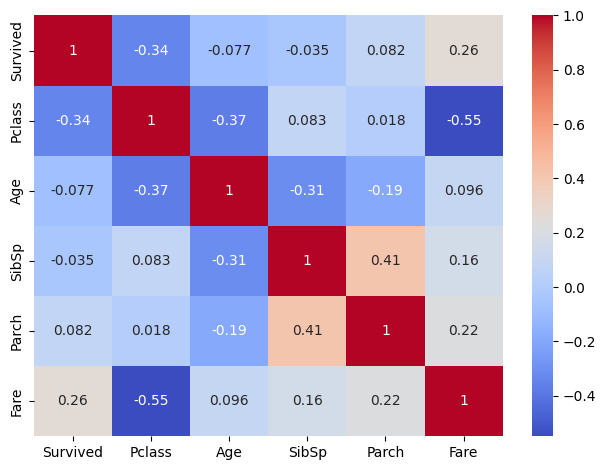

In [10]:
# 시각화를 위한 라이브러리 import
import seaborn as sns

# 상관관계 행렬을 히트맵으로 시각화
# annot=True: 각 셀에 상관계수 값 표시
# cmap="coolwarm": 색상 맵 설정 (파란색: 음의 상관, 빨간색: 양의 상관)
g = sns.heatmap(df_titanic.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.tight_layout()  # 레이아웃 정리
plt.show()  # 그래프 출력

가장 양의 상관 관계가 높은 feature 는 Fare 이고 Pclass 는 가장 음의 상관관계가 높은 것으로 나타난다.

### Missing Value 처리

In [11]:
# 결측치 개수 재확인
df_titanic.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [12]:
# 데이터셋 크기 확인
df_titanic.shape

(891, 8)

891 개의 data 중 177 개를 drop 시키는 것은 너무 많은 양이므로 Age 는 median 으로 채워주고 Embarked 는 drop 시킨다.

In [13]:
# Age 열의 결측치를 중앙값(median)으로 채우기
# 중앙값은 이상치에 덜 민감하므로 평균보다 안정적
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())
# 결측치 처리 후 확인
df_titanic.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [14]:
# 나머지 결측치가 있는 행 제거 (주로 Embarked 열)
# inplace=True: 원본 데이터프레임 수정
df_titanic.dropna(inplace=True)
# 결측치 제거 후 확인
df_titanic.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### Data 의 skewness  check

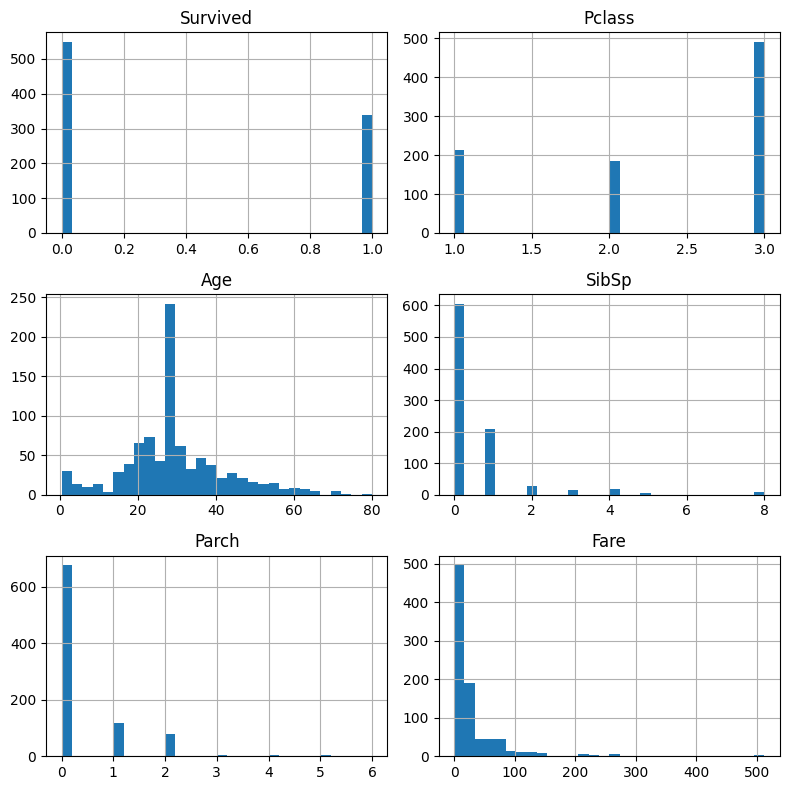

In [15]:
# 수치형 변수들의 분포 확인 (히스토그램)
# bins=30: 구간 개수, figsize=(8, 8): 그래프 크기
df_titanic.hist(bins=30, figsize=(8, 8));
plt.tight_layout()  # 레이아웃 정리
plt.show()  # 그래프 출력

### Fare 의 분포가 심하게 skew 되어 있으므로 log 값으로 바꾸어 skewness 를 완화 시킨다.

In [16]:
# Fare(요금) 변수에 로그 변환 적용
# 로그 변환은 왜도(skewness)를 줄여 정규분포에 가깝게 만듦
# lambda x: np.log(x) if x > 0 else 0: 0보다 큰 값만 로그 변환, 0은 그대로 유지
df_titanic['Fare'] = df_titanic['Fare'].map(lambda x: np.log(x) if x > 0 else 0)

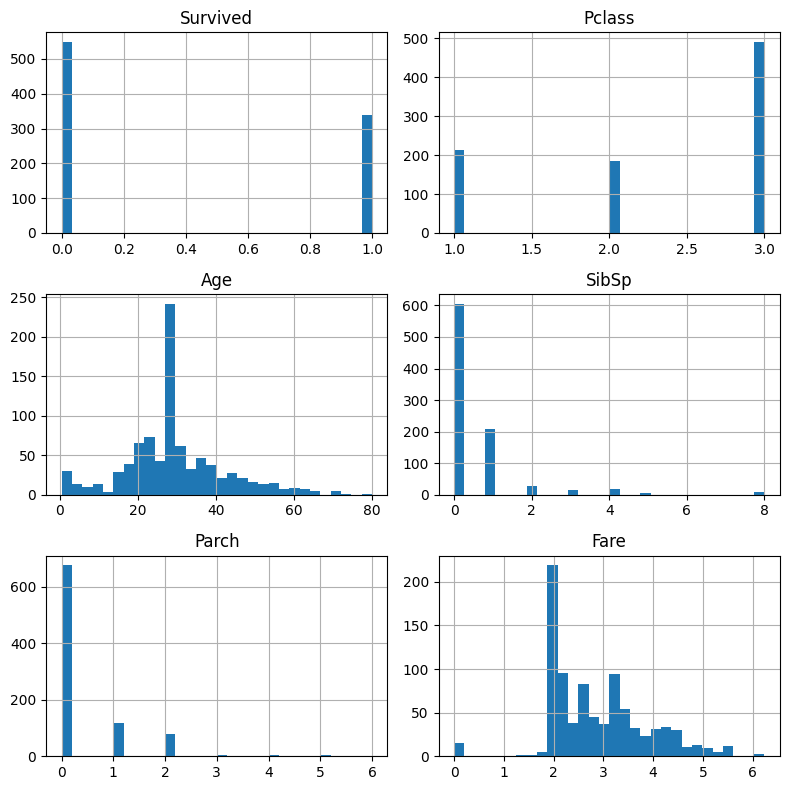

In [17]:
# 로그 변환 후 분포 재확인
df_titanic.hist(bins=30, figsize=(8, 8));
plt.tight_layout()  # 레이아웃 정리
plt.show()  # 그래프 출력

In [18]:
# 데이터 확인
df_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,1.981001,S
1,1,1,female,38.0,1,0,4.266662,C
2,1,3,female,26.0,0,0,2.070022,S
3,1,1,female,35.0,1,0,3.972177,S
4,0,3,male,35.0,0,0,2.085672,S


### Category 변수 처리

Category column 들을 one-hot-encoding 으로 변환한다.

In [19]:
# 범주형 변수를 원-핫 인코딩으로 변환
# get_dummies: 범주형 변수를 각 범주별로 이진(binary) 변수로 변환
# 예: Sex_male, Sex_female, Embarked_C, Embarked_Q, Embarked_S 등
df_titanic = pd.get_dummies(df_titanic)
# 변환 후 데이터 확인
df_titanic.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,1.981001,False,True,False,False,True
1,1,1,38.0,1,0,4.266662,True,False,True,False,False
2,1,3,26.0,0,0,2.070022,True,False,False,False,True
3,1,1,35.0,1,0,3.972177,True,False,False,False,True
4,0,3,35.0,0,0,2.085672,False,True,False,False,True


### Train / Test dataset split

In [20]:
# 데이터 분할 전 크기 확인
df_titanic.shape

(889, 11)

In [21]:
# 학습/테스트 데이터셋 분할
# 처음 700개 행을 학습용으로 사용
X_train = df_titanic[:700]
# 나머지 행을 테스트용으로 사용
X_test  = df_titanic[700:]

In [22]:
# 타겟 변수(Survived) 분리
# pop(): 해당 열을 추출하고 원본 데이터프레임에서 제거
y_train = X_train.pop('Survived')  # 학습용 타겟 변수
y_test  = X_test.pop('Survived')  # 테스트용 타겟 변수

### Standard Scaling

In [23]:
# 데이터 표준화를 위한 라이브러리 import
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
sc = StandardScaler()

# 학습 데이터에 대해 평균과 표준편차를 계산하고 변환
# fit_transform: 학습 데이터의 통계량을 계산하고 동시에 변환
X_train_scaled = sc.fit_transform(X_train)

# 테스트 데이터는 학습 데이터의 통계량을 사용하여 변환
# transform: 이미 계산된 통계량을 사용하여 변환만 수행
X_test_scaled = sc.transform(X_test)

## Random Forest Model

In [24]:
# 랜덤 포레스트 분류기 import
from sklearn.ensemble import RandomForestClassifier  

# 랜덤 포레스트 분류기 모델 생성
# n_estimators=10: 결정 트리 개수 (앙상블에 사용할 트리 수)
# criterion='entropy': 분할 기준 (엔트로피 사용)
# random_state=0: 재현 가능한 결과를 위한 랜덤 시드 설정
rf = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)

# 훈련 데이터(X_train_scaled, y_train)를 사용하여 모델 학습
rf.fit(X_train_scaled, y_train)

,n_estimators,10
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# 테스트 데이터(X_test_scaled)에 대해 학습된 모델로 예측 수행
y_pred = rf.predict(X_test_scaled)

# 테스트 세트에서 실제 값이 True(또는 1, 생존)인 샘플 수 출력
print("Test set true counts = ", sum(y_test))

# 예측 결과에서 True(또는 1, 생존)로 예측된 샘플 수 출력
print("predicted true counts = ", sum(y_pred))

# 정확도 계산 및 출력 (예측이 정답과 일치하는 비율)
print("accuracy = {:.2f}".format(sum(y_pred == y_test) / len(y_test)))

Test set true counts =  69
predicted true counts =  70
accuracy = 0.85


### Feature Importance 시각화

In [26]:
# 랜덤 포레스트 모델의 특성 중요도 확인
# feature_importances_: 각 특성이 예측에 기여한 정도
rf.feature_importances_

array([0.09695869, 0.26475999, 0.03734466, 0.0412327 , 0.27531019,
       0.07043718, 0.17363033, 0.01656018, 0.00794812, 0.01581796])

In [27]:
# 학습된 랜덤 포레스트 모델로부터 각 특성(feature)의 중요도를 가져와 시리즈로 생성
# 인덱스는 X_train의 컬럼명, 값은 중요도
# sort_values(ascending=False): 중요도 기준으로 내림차순 정렬
feature_imp = pd.Series(rf.feature_importances_, 
            X_train.columns).sort_values(ascending=False)

# 정렬된 특성 중요도 출력
feature_imp

Fare          0.275310
Age           0.264760
Sex_male      0.173630
Pclass        0.096959
Sex_female    0.070437
Parch         0.041233
SibSp         0.037345
Embarked_C    0.016560
Embarked_S    0.015818
Embarked_Q    0.007948
dtype: float64

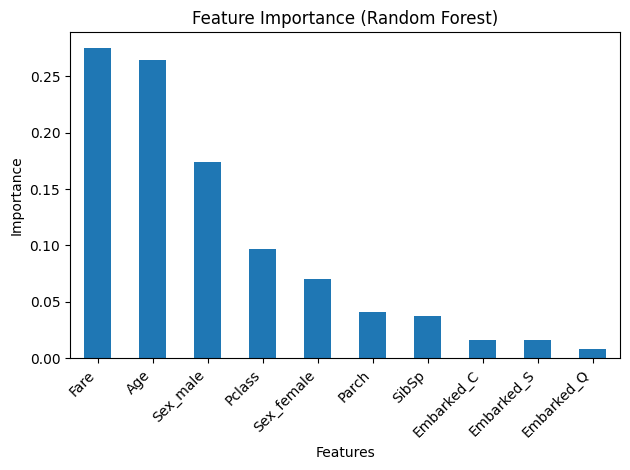

In [28]:
# 특성 중요도를 막대그래프로 시각화
feature_imp.plot(kind='bar', title='Feature Importance (Random Forest)')
plt.xlabel('Features')  # x축 레이블
plt.ylabel('Importance')  # y축 레이블
plt.xticks(rotation=45, ha='right')  # x축 레이블 회전 (가독성 향상)
plt.tight_layout()  # 레이아웃 정리
plt.show()  # 그래프 출력

## Gradient Boosting Classifier

- min_samples_split : node 분리에 필요한 최소 sample 수 => overfitting 방지  
- max_depth : tree 깊이 조절 => overfitting 방지
- learning_rate : 각 tree 의 기여도 조정, n_estimators 와 trade-off 
- n_estimators : number of sequential trees

In [29]:
# 그래디언트 부스팅 분류기 import
from sklearn.ensemble import GradientBoostingClassifier  

# Gradient Boosting 모델 생성
# learning_rate=0.1: 학습률 (각 트리의 기여도, 낮을수록 더 많은 트리 필요)
# n_estimators=100: 약한 학습기(트리) 개수 (순차적으로 생성되는 트리 수)
# max_depth=5: 각 트리의 최대 깊이 (과적합 방지)
gb = GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_depth=5)

# 훈련 데이터(X_train_scaled, y_train)를 사용하여 모델 학습
gb.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [30]:
# 테스트 데이터(X_test_scaled)에 대해 학습된 그래디언트 부스팅 모델로 예측 수행
y_pred = gb.predict(X_test_scaled)

print()  

# 테스트 세트에서 실제로 True(또는 1, 생존)인 샘플 수 출력
print("Test set true counts = ", sum(y_test))

# 예측 결과에서 True(또는 1, 생존)로 예측된 샘플 수 출력
print("predicted true counts = ", sum(y_pred))

# 정확도 계산 및 출력 (예측이 정답과 일치하는 비율)
print("accuracy = {:.2f}".format(sum(y_pred == y_test) / len(y_test)))


Test set true counts =  69
predicted true counts =  71
accuracy = 0.86


In [31]:
# 학습된 그래디언트 부스팅 모델로부터 각 특성의 중요도를 가져와 시리즈로 생성
# 인덱스는 X_train의 컬럼명, 값은 해당 특성의 중요도
# sort_values(ascending=False): 중요도 기준 내림차순 정렬
feature_imp = pd.Series(gb.feature_importances_, 
            X_train.columns).sort_values(ascending=False)

# 정렬된 특성 중요도 출력
feature_imp

Fare          0.279313
Age           0.195475
Sex_male      0.178513
Sex_female    0.177710
Pclass        0.104578
SibSp         0.033962
Embarked_S    0.012000
Parch         0.008458
Embarked_C    0.007354
Embarked_Q    0.002636
dtype: float64

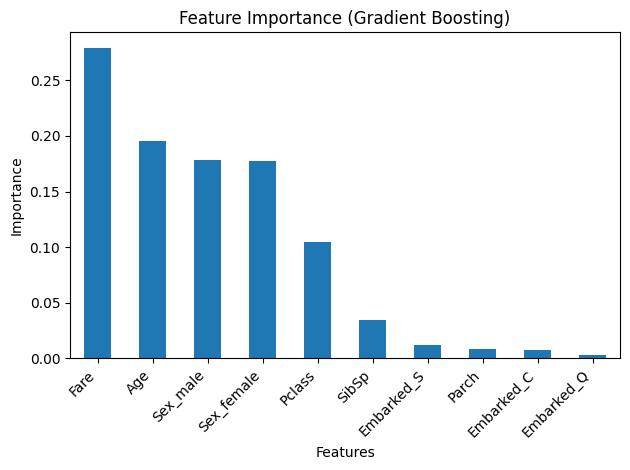

In [32]:
# 특성 중요도를 막대그래프로 시각화
feature_imp.plot(kind='bar', title='Feature Importance (Gradient Boosting)')
plt.xlabel('Features')  # x축 레이블
plt.ylabel('Importance')  # y축 레이블
plt.xticks(rotation=45, ha='right')  # x축 레이블 회전 (가독성 향상)
plt.tight_layout()  # 레이아웃 정리
plt.show()  # 그래프 출력